# **ECG**

🚀 Running on device: cuda
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating rec

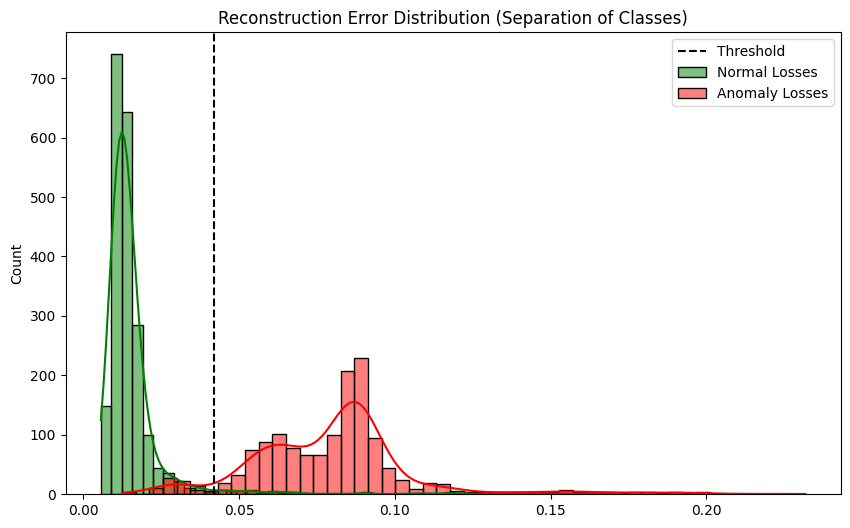

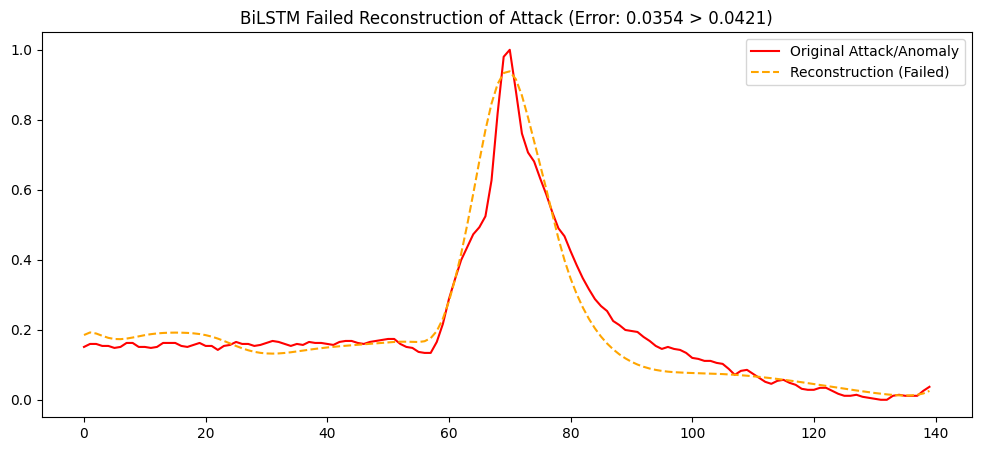

In [ ]:
import os
import wfdb
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Running on device: {device}")

DB_NAME = 'mitdb'
DOWNLOAD_PATH = 'mitdb_data'
WINDOW_SIZE = 140  # Fixed window for one heartbeat
BATCH_SIZE = 64
EPOCHS = 30        # Increased epochs for better convergence

# ==========================================
# 2. DATA LOADING (Same robust logic)
# ==========================================
def load_mit_bih_data(download_dir):
    if not os.path.exists(download_dir):
        os.makedirs(download_dir)
        print("Downloading MIT-BIH Database...")
        wfdb.dl_database('mitdb', download_dir)

    # Use a subset for demonstration speed, or remove list to use ALL files
    records = ['100', '101', '102', '103', '104', '105', '106', '107']

    X_segments = []
    y_labels = []
    normal_symbols = ['N', 'L', 'R', 'e', 'j']

    print("Processing ECG records...")
    for rec in records:
        try:
            path = os.path.join(download_dir, rec)
            record = wfdb.rdsamp(path)
            annotation = wfdb.rdann(path, 'atr')
            signal = record[0][:, 0] # Lead II
            peaks = annotation.sample
            symbols = annotation.symbol

            for peak, symbol in zip(peaks, symbols):
                start, end = peak - WINDOW_SIZE//2, peak + WINDOW_SIZE//2
                if start < 0 or end > len(signal): continue

                segment = signal[start:end]

                # Filter: Skip flatlines or extreme noise
                if np.max(segment) - np.min(segment) < 0.05: continue

                # Normalize (MinMax per segment is crucial for Autoencoders)
                segment = (segment - np.min(segment)) / (np.max(segment) - np.min(segment) + 1e-8)

                X_segments.append(segment)
                y_labels.append(0 if symbol in normal_symbols else 1)
        except:
            pass

    return np.array(X_segments), np.array(y_labels)

# Load and Process
X, y = load_mit_bih_data(DOWNLOAD_PATH)
X = X.reshape(X.shape[0], X.shape[1], 1) # [Batch, Seq, Feature]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ISOLATE NORMAL DATA FOR TRAINING
X_train_normal = X_train[y_train == 0]
X_test_normal = X_test[y_test == 0] # For validation
X_test_anomaly = X_test[y_test == 1] # For testing

# Convert to Tensors
train_tensor = torch.tensor(X_train_normal, dtype=torch.float32).to(device)
test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

train_loader = DataLoader(TensorDataset(train_tensor, train_tensor), batch_size=BATCH_SIZE, shuffle=True)

print(f"✅ Data Ready. Normal Train Samples: {len(X_train_normal)}")

# ==========================================
# 3. ENHANCED BiLSTM AUTOENCODER MODEL
# ==========================================
class BiLSTM_Autoencoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=64):
        super(BiLSTM_Autoencoder, self).__init__()
        self.seq_len = seq_len

        # ENCODER (Bidirectional)
        # Input: [Batch, Seq, 1] -> Output: [Batch, Seq, Enc_Hidden*2]
        self.encoder = nn.LSTM(
            input_size=n_features,
            hidden_size=embedding_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        # DECODER (Bidirectional)
        # Input size doubles because Encoder was bidirectional
        self.decoder = nn.LSTM(
            input_size=embedding_dim * 2,
            hidden_size=embedding_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        # OUTPUT LAYER
        # Projects back to 1 feature.
        # Input is embedding_dim * 2 (because Decoder is also bidirectional)
        self.output_layer = nn.Linear(embedding_dim * 2, n_features)

        # Dropout for regularization
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # 1. Encode
        # enc_output shape: [Batch, Seq, Embedding*2]
        enc_output, (hidden, cell) = self.encoder(x)

        # 2. Bottleneck Strategy
        # We take the last hidden state to represent the whole context
        # Hidden shape: [Num_Layers*Num_Dirs, Batch, Hid_Dim]
        # We concatenate the forward and backward hidden states
        hidden_cat = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1) # [Batch, Embedding*2]

        # 3. Repeat Vector (Prepare for Decoder)
        # Replicate the context vector for every timestep
        x_repeated = hidden_cat.unsqueeze(1).repeat(1, self.seq_len, 1)

        # 4. Decode
        x_decoded, _ = self.decoder(x_repeated)
        x_decoded = self.dropout(x_decoded)

        # 5. Final Reconstruction
        reconstruction = self.output_layer(x_decoded)
        return reconstruction

# Initialize Model
model = BiLSTM_Autoencoder(seq_len=WINDOW_SIZE, n_features=1, embedding_dim=64).to(device)
criterion = nn.L1Loss() # MAE often works better than MSE for signal reconstruction
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 4. TRAINING LOOP
# ==========================================
print("Starting BiLSTM Training...")
history = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for data in train_loader:
        inputs = data[0]

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs) # Compare Reconstruction vs Original
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    history.append(avg_loss)
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.6f}")

# SAVE THE MODEL
MODEL_PATH = "/content/drive/MyDrive/IoHT/ecg_bilstm_autoencoder.pth"
torch.save(model.state_dict(), MODEL_PATH)
print(f"💾 Model saved to {MODEL_PATH}")

# ==========================================
# 5. EVALUATION & DYNAMIC THRESHOLDING
# ==========================================
model.eval()
with torch.no_grad():
    # Get reconstruction errors for Normal Test Data
    normal_preds = model(torch.tensor(X_test_normal, dtype=torch.float32).to(device))
    # Calculate MAE per sample
    normal_losses = torch.mean(torch.abs(normal_preds - torch.tensor(X_test_normal).to(device)), dim=[1,2]).cpu().numpy()

    # Get reconstruction errors for Anomaly Test Data
    anomaly_preds = model(torch.tensor(X_test_anomaly, dtype=torch.float32).to(device))
    anomaly_losses = torch.mean(torch.abs(anomaly_preds - torch.tensor(X_test_anomaly).to(device)), dim=[1,2]).cpu().numpy()

# --- DYNAMIC THRESHOLD CALCULATION ---
# We set the threshold at Mean(Normal) + 2 Standard Deviations
# This ensures ~95% of normal data is accepted, everything else is flagged.
THRESHOLD = np.mean(normal_losses) + 2 * np.std(normal_losses)
print(f"\n📊 Calculated Threshold: {THRESHOLD:.5f}")

# Calculate Accuracy
tp = np.sum(anomaly_losses > THRESHOLD) # True Positives (Anomaly detected as Anomaly)
tn = np.sum(normal_losses <= THRESHOLD) # True Negatives (Normal detected as Normal)
fp = np.sum(normal_losses > THRESHOLD)  # False Positives (Normal flagged as Anomaly)
fn = np.sum(anomaly_losses <= THRESHOLD)# False Negatives (Anomaly missed)

accuracy = (tp + tn) / (tp + tn + fp + fn)
print(f"✅ Model Accuracy: {accuracy * 100:.2f}%")
print(f"   True Positives (Attacks Detected): {tp}/{len(anomaly_losses)}")

# ==========================================
# 6. VISUALIZATION
# ==========================================
# Plot Loss Distribution
plt.figure(figsize=(10, 6))
sns.histplot(normal_losses, bins=50, kde=True, color='green', label='Normal Losses')
sns.histplot(anomaly_losses, bins=50, kde=True, color='red', label='Anomaly Losses')
plt.axvline(THRESHOLD, color='black', linestyle='--', label='Threshold')
plt.title('Reconstruction Error Distribution (Separation of Classes)')
plt.legend()
plt.show()

# Plot Sample Reconstruction
idx = 0
plt.figure(figsize=(12, 5))
plt.plot(X_test_anomaly[idx], label='Original Attack/Anomaly', color='red')
plt.plot(anomaly_preds[idx].cpu().numpy(), label='Reconstruction (Failed)', color='orange', linestyle='--')
plt.title(f"BiLSTM Failed Reconstruction of Attack (Error: {anomaly_losses[idx]:.4f} > {THRESHOLD:.4f})")
plt.legend()
plt.show()

🚀 Training on: cuda
⏳ Processing Records...
✅ Data Ready. Train: 297088 | Val: 74272
🔥 Starting Training...
Epoch 1/50 | Train Loss: 0.01742 | Val Loss: 0.01078 ✅ New Best!
Epoch 2/50 | Train Loss: 0.00808 | Val Loss: 0.00601 ✅ New Best!
Epoch 3/50 | Train Loss: 0.00630 | Val Loss: 0.00492 ✅ New Best!
Epoch 4/50 | Train Loss: 0.00565 | Val Loss: 0.00406 ✅ New Best!
Epoch 5/50 | Train Loss: 0.00518 | Val Loss: 0.00504 ⏳ (1/7)
Epoch 6/50 | Train Loss: 0.00485 | Val Loss: 0.00503 ⏳ (2/7)
Epoch 7/50 | Train Loss: 0.00450 | Val Loss: 0.00530 ⏳ (3/7)
Epoch 8/50 | Train Loss: 0.00438 | Val Loss: 0.00355 ✅ New Best!
Epoch 9/50 | Train Loss: 0.00403 | Val Loss: 0.00805 ⏳ (1/7)
Epoch 10/50 | Train Loss: 0.00373 | Val Loss: 0.00248 ✅ New Best!
Epoch 11/50 | Train Loss: 0.00329 | Val Loss: 0.00567 ⏳ (1/7)
Epoch 12/50 | Train Loss: 0.00306 | Val Loss: 0.00332 ⏳ (2/7)
Epoch 13/50 | Train Loss: 0.00296 | Val Loss: 0.00358 ⏳ (3/7)
Epoch 14/50 | Train Loss: 0.00282 | Val Loss: 0.00217 ✅ New Best!
Epoch

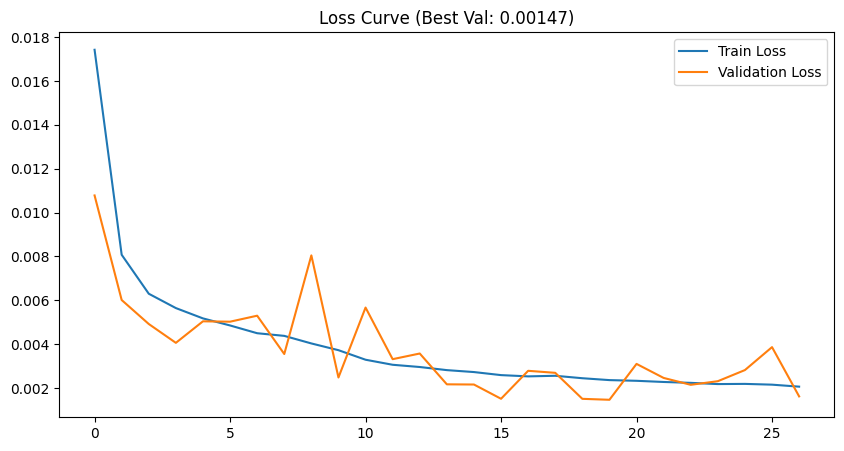

Sample Reconstruction Loss: 0.00090


In [ ]:
import os
import wfdb
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import copy

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Training on: {device}")

DOWNLOAD_PATH = 'mitdb_data'
WINDOW_SIZE = 140
BATCH_SIZE = 64
EPOCHS = 50        # High number, Early Stopping will cut it short
PATIENCE = 7        # Stop if no improvement for 7 epochs

# ==========================================
# 2. DATA LOADING
# ==========================================
def load_data():
    if not os.path.exists(DOWNLOAD_PATH):
        print("Downloading MIT-BIH Database...")
        wfdb.dl_database('mitdb', DOWNLOAD_PATH)

    # We use a mix of records to generalize well
    records = ['100','101','102','103','104','105','106','107','108','109',
               '111','112','113','114','115','116','117','118','119','121']

    X_segments = []

    print("⏳ Processing Records...")
    for rec in records:
        try:
            path = os.path.join(DOWNLOAD_PATH, rec)
            record = wfdb.rdsamp(path)
            signal = record[0][:, 0] # Lead II

            # 1. Global Normalization (Z-Score)
            signal = (signal - np.mean(signal)) / np.std(signal)

            # 2. Sliding Window (Step 35 for more data overlap)
            for i in range(0, len(signal) - WINDOW_SIZE, 35):
                segment = signal[i:i+WINDOW_SIZE]
                X_segments.append(segment)
        except: pass

    return np.array(X_segments)

# Load and Reshape
X = load_data()
X = X.reshape(X.shape[0], WINDOW_SIZE, 1)

# Split (Train on 80%, Validate on 20%)
X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

# Create Loaders
train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32).to(device),
                                        torch.tensor(X_train, dtype=torch.float32).to(device)),
                          batch_size=BATCH_SIZE, shuffle=True)

val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32).to(device),
                                      torch.tensor(X_val, dtype=torch.float32).to(device)),
                        batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Data Ready. Train: {len(X_train)} | Val: {len(X_val)}")

# ==========================================
# 3. HYBRID MODEL (CNN-BiLSTM)
# ==========================================
class Hybrid_Autoencoder(nn.Module):
    def __init__(self):
        super(Hybrid_Autoencoder, self).__init__()
        # Encoder
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, padding=3)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.lstm_enc = nn.LSTM(32, 64, batch_first=True, bidirectional=True)

        # Decoder
        self.lstm_dec = nn.LSTM(128, 64, batch_first=True, bidirectional=True)
        self.upsample = nn.Upsample(scale_factor=2)
        self.conv2 = nn.Conv1d(128, 1, kernel_size=7, padding=3)

    def forward(self, x):
        # [Batch, 140, 1] -> [Batch, 1, 140]
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x) # -> [Batch, 32, 70]

        # LSTM needs [Batch, Seq, Feat]
        x = x.permute(0, 2, 1) # -> [Batch, 70, 32]
        x, _ = self.lstm_enc(x)
        x, _ = self.lstm_dec(x)

        # Back to CNN shape
        x = x.permute(0, 2, 1) # -> [Batch, 128, 70]
        x = self.upsample(x)
        x = self.conv2(x)      # -> [Batch, 1, 140]

        x = x.permute(0, 2, 1) # -> [Batch, 140, 1]
        return x

model = Hybrid_Autoencoder().to(device)
criterion = nn.L1Loss() # MAE is better for ECG spikes
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 4. TRAINING WITH EARLY STOPPING
# ==========================================
history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
best_weights = copy.deepcopy(model.state_dict())
no_improve_count = 0

print("🔥 Starting Training...")

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    train_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATE ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # Record Stats
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}", end="")

    # --- EARLY STOPPING LOGIC ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_weights = copy.deepcopy(model.state_dict())
        no_improve_count = 0
        print(" ✅ New Best!")
    else:
        no_improve_count += 1
        print(f" ⏳ ({no_improve_count}/{PATIENCE})")

        if no_improve_count >= PATIENCE:
            print("\n🛑 Early Stopping Triggered! Model stopped improving.")
            break

# ==========================================
# 5. SAVE & PLOT
# ==========================================
# Save the BEST weights, not the last ones
model.load_state_dict(best_weights)
torch.save(model.state_dict(), "/content/drive/MyDrive/IoHT/ecg_bilstm_autoencoder.pth")
print(f"💾 Best Model Saved (Val Loss: {best_val_loss:.5f})")

plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title(f'Loss Curve (Best Val: {best_val_loss:.5f})')
plt.legend()
plt.show()

# Quick Sanity Check
model.eval()
with torch.no_grad():
    sample = torch.tensor(X_val[0:1], dtype=torch.float32).to(device)
    recon = model(sample)
    loss = criterion(recon, sample).item()
    print(f"Sample Reconstruction Loss: {loss:.5f}")

In [ ]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 48.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
